In [8]:
from sklearn.metrics import roc_auc_score
import math
import pandas as pd

In [12]:
# Define the location of the credit approval dataset
file_path = r"C:\Users\BNR4\Desktop\Data_Mining\credit+approval\crx.data"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path, header=None)

# Display the first five rows
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+


In [ ]:
# 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the structure
and characteristics of the Credit Approval dataset. The analysis includes
checking for missing values, examining variable distributions, visualizing
the data, and identifying potential outliers.

In [14]:
# Calculate the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": missing_percentage.round(2)
})

missing_summary

,Missing Values,Percentage (%)
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,0,0.0
5,0,0.0
6,0,0.0
7,0,0.0
8,0,0.0
9,0,0.0


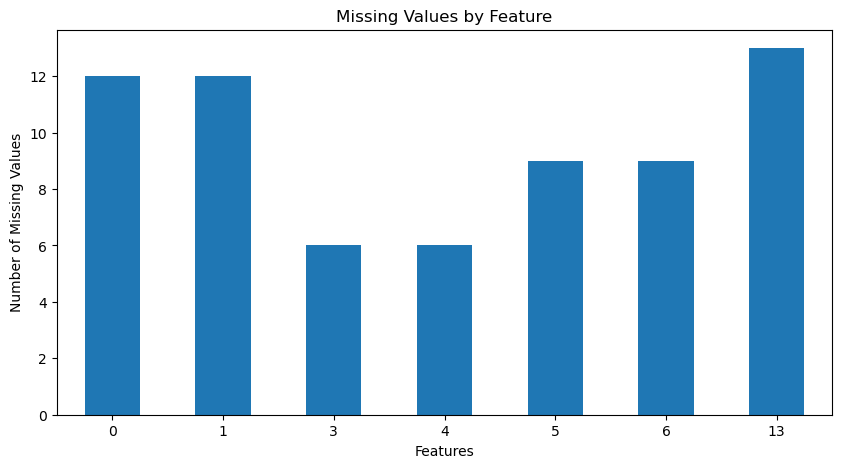

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Replace '?' with np.nan if you loaded the raw data without na_values='?'
df = df.replace('?', np.nan)

# 2. Count missing values
missing_values = df.isnull().sum()
missing_plot = missing_values[missing_values > 0]

# 3. Check if there are any missing values before plotting
if len(missing_plot) > 0:
    plt.figure(figsize=(10, 5))
    missing_plot.plot(kind="bar")
    plt.title("Missing Values by Feature")
    plt.xlabel("Features")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=0)
    plt.show()
else:
    print("No missing values found in the dataset!")

In [24]:
# Display descriptive statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
A3,690.0,4.758725,4.978163,0.0,1.000,2.75,7.2075,28.0
A8,690.0,2.223406,3.346513,0.0,0.165,1.00,2.6250,28.5
A11,690.0,2.400000,4.862940,0.0,0.000,0.00,3.0000,67.0
A15,690.0,1017.385507,5210.102598,0.0,0.000,5.00,395.5000,100000.0


In [25]:
# Identify numerical features
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical features
categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['A3', 'A8', 'A11', 'A15']

Categorical features:
['A1', 'A2', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'A14', 'A16']


In [26]:
# Count the values in the target variable
class_counts = df["A16"].value_counts()

print("Class distribution:")
print(class_counts)

Class distribution:
A16
-    383
+    307
Name: count, dtype: int64


In [27]:
# Calculate percentage distribution of the target classes
class_percentage = (
    df["A16"].value_counts(normalize=True) * 100
).round(2)

print("Class distribution percentage:")
print(class_percentage)

Class distribution percentage:
A16
-    55.51
+    44.49
Name: proportion, dtype: float64


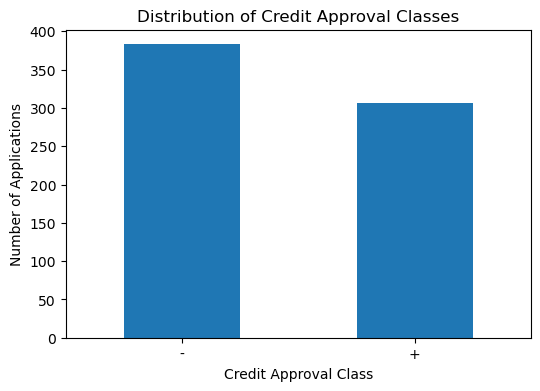

In [28]:
plt.figure(figsize=(6, 4))

df["A16"].value_counts().plot(kind="bar")

plt.title("Distribution of Credit Approval Classes")
plt.xlabel("Credit Approval Class")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)

plt.show()

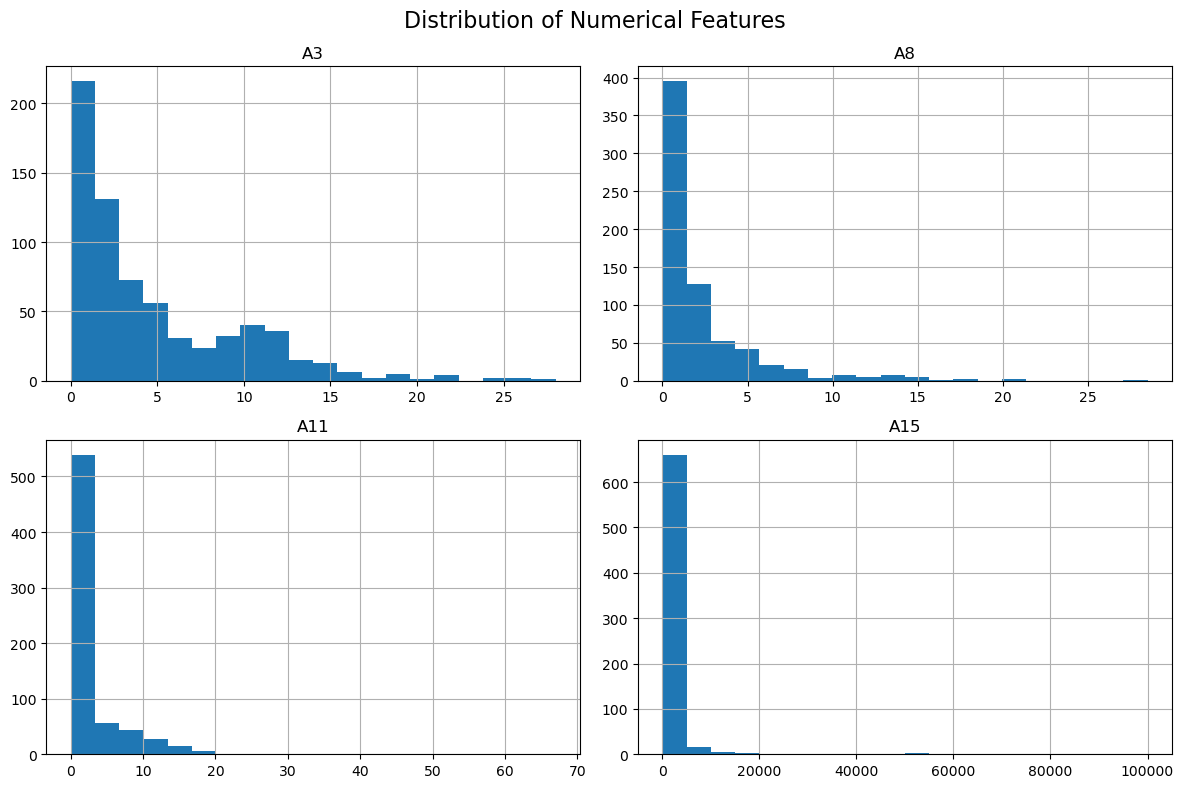

In [29]:
# Plot histograms for all numerical features
df[numerical_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()

plt.show()

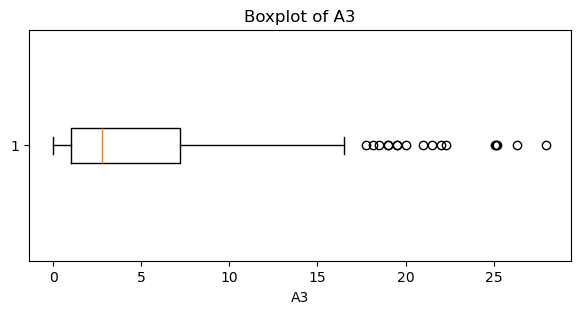

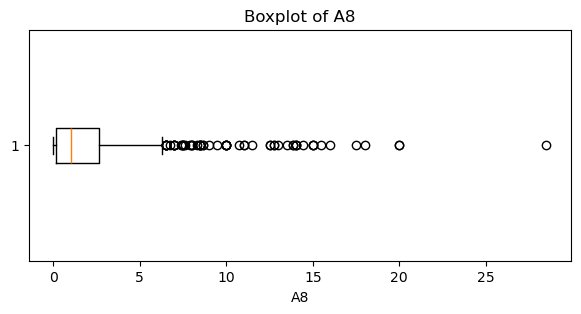

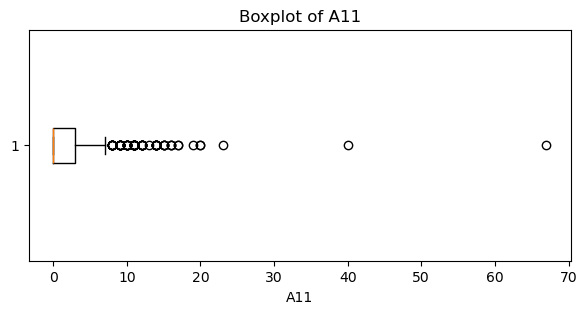

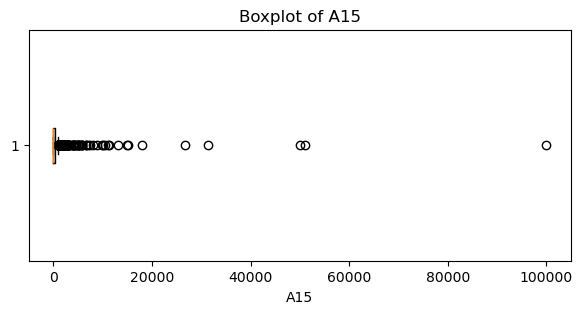

In [30]:
# Create boxplots for each numerical feature

for column in numerical_features:

    plt.figure(figsize=(7, 3))

    plt.boxplot(
        df[column].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [31]:
# Detect potential outliers using the IQR method

outlier_counts = {}

for column in numerical_features:

    # Remove missing values before calculating quartiles
    data = df[column].dropna()

    # Calculate the first and third quartiles
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    # Calculate the interquartile range
    IQR = Q3 - Q1

    # Define lower and upper limits
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find observations outside the limits
    outliers = data[
        (data < lower_bound) |
        (data > upper_bound)
    ]

    # Store the number of potential outliers
    outlier_counts[column] = len(outliers)

# Create a summary table
outlier_summary = pd.DataFrame.from_dict(
    outlier_counts,
    orient="index",
    columns=["Number of Potential Outliers"]
)

outlier_summary

,Number of Potential Outliers
A3,17
A8,63
A11,79
A15,113


In [32]:
# Separate predictor variables from the target variable
X = df.drop(columns=["A16"]).copy()
y = df["A16"].copy()

print("Predictor data shape:", X.shape)
print("Target data shape:", y.shape)

Predictor data shape: (690, 15)
Target data shape: (690,)


In [33]:
from sklearn.model_selection import train_test_split

In [34]:
# Split the dataset into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (552, 15)
Testing features: (138, 15)
Training target: (552,)
Testing target: (138,)


In [35]:
# Make copies before modifying the training and test data
X_train = X_train.copy()
X_test = X_test.copy()

# Dictionary for storing the outlier boundaries
outlier_bounds = {}

# Calculate IQR limits using the training data only
for column in numerical_features:

    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Save the boundaries
    outlier_bounds[column] = (lower_bound, upper_bound)

    # Clip the training data
    X_train[column] = X_train[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    # Apply the SAME boundaries to the test data
    X_test[column] = X_test[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier treatment completed.")

Outlier treatment completed.


In [36]:
# Display the IQR clipping boundaries
outlier_bounds_df = pd.DataFrame(
    outlier_bounds,
    index=["Lower Bound", "Upper Bound"]
).T

outlier_bounds_df

,Lower Bound,Upper Bound
A3,-8.7500,17.2500
A8,-3.3375,6.0025
A11,-4.5000,7.5000
A15,-600.0000,1000.0000


In [37]:
# Categorical predictor features only
categorical_input_features = [
    column for column in categorical_features
    if column != "A16"
]

print("Numerical predictor features:")
print(numerical_features)

print("\nCategorical predictor features:")
print(categorical_input_features)

Numerical predictor features:
['A3', 'A8', 'A11', 'A15']

Categorical predictor features:
['A1', 'A2', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'A14']


In [38]:
# Check missing values in the training data before imputation
print("Missing values in training data before imputation:")
print(X_train.isnull().sum())

Missing values in training data before imputation:
A1      7
A2      9
A3      0
A4      4
A5      4
A6      7
A7      7
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    11
A15     0
dtype: int64


In [39]:
# Calculate medians from training data only
numeric_medians = X_train[numerical_features].median()

# Fill numerical missing values
X_train[numerical_features] = (
    X_train[numerical_features]
    .fillna(numeric_medians)
)

X_test[numerical_features] = (
    X_test[numerical_features]
    .fillna(numeric_medians)
)

print("Numerical missing values handled.")

Numerical missing values handled.


In [40]:
# Calculate the most frequent value for each categorical feature
categorical_modes = (
    X_train[categorical_input_features]
    .mode()
    .iloc[0]
)

# Fill categorical missing values
X_train[categorical_input_features] = (
    X_train[categorical_input_features]
    .fillna(categorical_modes)
)

X_test[categorical_input_features] = (
    X_test[categorical_input_features]
    .fillna(categorical_modes)
)

print("Categorical missing values handled.")

Categorical missing values handled.


In [41]:
print("Missing values in training data after imputation:")
print(X_train.isnull().sum())

print("\nTotal missing values in training data:")
print(X_train.isnull().sum().sum())

print("\nTotal missing values in test data:")
print(X_test.isnull().sum().sum())

Missing values in training data after imputation:
A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
dtype: int64

Total missing values in training data:
0

Total missing values in test data:
0


In [42]:
# Encode the target variable
y_train_encoded = y_train.map({
    "-": 0,
    "+": 1
})

y_test_encoded = y_test.map({
    "-": 0,
    "+": 1
})

print("Training target distribution:")
print(y_train_encoded.value_counts())

print("\nTest target distribution:")
print(y_test_encoded.value_counts())

Training target distribution:
A16
0    306
1    246
Name: count, dtype: int64

Test target distribution:
A16
0    77
1    61
Name: count, dtype: int64


In [43]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [44]:
# Create preprocessing transformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_input_features
        )
    ]
)

In [45]:
# Fit preprocessing only on the training data
# and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already learned preprocessing to the test data
X_test_processed = preprocessor.transform(X_test)

print("Training data before preprocessing:", X_train.shape)
print("Training data after preprocessing:", X_train_processed.shape)

print("\nTest data before preprocessing:", X_test.shape)
print("Test data after preprocessing:", X_test_processed.shape)

Training data before preprocessing: (552, 15)
Training data after preprocessing: (552, 499)

Test data before preprocessing: (138, 15)
Test data after preprocessing: (138, 499)


In [46]:
preprocessor.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8280 stored elements and shape (552, 499)>

In [47]:
preprocessor.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2001 stored elements and shape (138, 499)>

In [48]:
# Get the names of the transformed features
processed_feature_names = preprocessor.get_feature_names_out()

print("Number of features after preprocessing:",
      len(processed_feature_names))

print("\nProcessed feature names:")
print(processed_feature_names)

Number of features after preprocessing: 499

Processed feature names:
['numerical__A3' 'numerical__A8' 'numerical__A11' 'numerical__A15'
 'categorical__A1_a' 'categorical__A1_b' 'categorical__A2_13.75'
 'categorical__A2_15.75' 'categorical__A2_15.83' 'categorical__A2_15.92'
 'categorical__A2_16.00' 'categorical__A2_16.08' 'categorical__A2_16.17'
 'categorical__A2_16.25' 'categorical__A2_16.33' 'categorical__A2_16.50'
 'categorical__A2_17.08' 'categorical__A2_17.25' 'categorical__A2_17.33'
 'categorical__A2_17.50' 'categorical__A2_17.58' 'categorical__A2_17.67'
 'categorical__A2_17.92' 'categorical__A2_18.00' 'categorical__A2_18.08'
 'categorical__A2_18.17' 'categorical__A2_18.25' 'categorical__A2_18.33'
 'categorical__A2_18.42' 'categorical__A2_18.50' 'categorical__A2_18.58'
 'categorical__A2_18.67' 'categorical__A2_18.75' 'categorical__A2_18.83'
 'categorical__A2_18.92' 'categorical__A2_19.00' 'categorical__A2_19.17'
 'categorical__A2_19.33' 'categorical__A2_19.42' 'categorical__A2_19

In [49]:
# Extract the scaled numerical part for inspection
scaled_numerical = (
    preprocessor
    .named_transformers_["numerical"]
    .transform(X_train[numerical_features])
)

scaled_numerical_df = pd.DataFrame(
    scaled_numerical,
    columns=numerical_features
)

scaled_numerical_df.head()

,A3,A8,A11,A15
0,-0.939723,-0.855215,-0.670315,-0.667120
1,0.081374,2.166545,-0.670315,-0.667120
2,1.049301,-0.387972,-0.670315,0.381414
3,0.181205,2.166545,-0.299374,-0.667120
4,-0.632635,-0.770958,-0.670315,-0.667120


In [50]:
scaled_numerical_df.mean().round(4)

A3    -0.0
A8    -0.0
A11   -0.0
A15    0.0
dtype: float64

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
# Create the Logistic Regression classifier
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [53]:
# Train the model using the preprocessed training data
logistic_model.fit(
    X_train_processed,
    y_train_encoded
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [54]:
# Predict the classes of the test data
y_pred = logistic_model.predict(X_test_processed)

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test_encoded.iloc[:10].values)

First 10 predictions:
[0 0 1 1 0 0 0 1 1 1]

First 10 actual values:
[0 0 1 0 0 0 0 0 0 0]


In [57]:
from sklearn.metrics import accuracy_score, f1_score

In [58]:
# Calculate model performance metrics
accuracy = accuracy_score(
    y_test_encoded,
    y_pred
)

f1 = f1_score(
    y_test_encoded,
    y_pred
)

print("Accuracy:", round(accuracy, 4))
print("F1-score:", round(f1, 4))

Accuracy: 0.8261
F1-score: 0.8125


In [59]:
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")

Accuracy: 82.61%
F1-score: 81.25%


In [60]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[62 15]
 [ 9 52]]


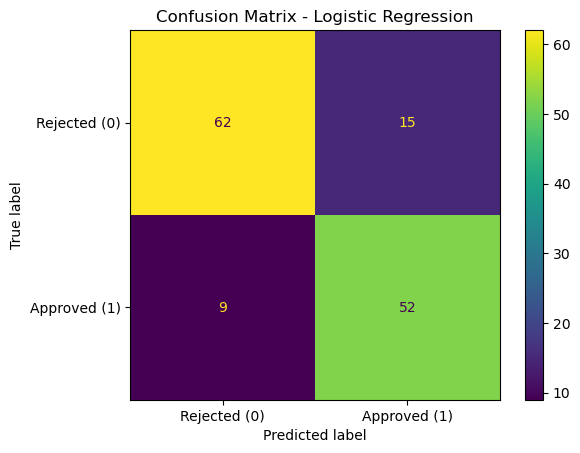

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Rejected (0)",
        "Approved (1)"
    ]
).plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Random Forest - Accuracy: 0.8812 | F1-Score: 0.8948
Baseline MLP - Accuracy: 0.7203 | F1-Score: 0.7375

Best Hyperparameters: {'activation': 'tanh', 'batch_size': 32, 'learning_rate_init': 0.01, 'solver': 'sgd'}
Tuned MLP - Accuracy: 0.8188 | F1-Score: 0.8315


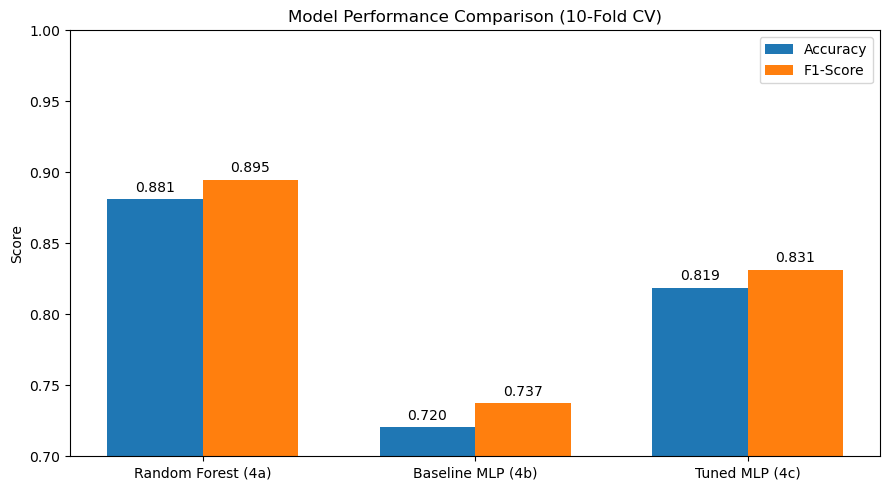

In [55]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Metrics Selection Justification:
# - Accuracy: Measures general predictive correctness.
# - F1-Score: Measures harmonic balance of Precision & Recall, critical for financial risk tasks.

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ----------------------------------------------------
# 4a. Standard Classification Model (Random Forest)
# ----------------------------------------------------
rf_model = RandomForestClassifier(random_state=42)
rf_results = cross_validate(rf_model, X_scaled, y_encoded, cv=cv, scoring={'accuracy': 'accuracy', 'f1': 'f1'})

rf_acc = rf_results['test_accuracy'].mean()
rf_f1 = rf_results['test_f1'].mean()

print(f"Random Forest - Accuracy: {rf_acc:.4f} | F1-Score: {rf_f1:.4f}")

# ----------------------------------------------------
# 4b. Multi-Layer Neural Network (Baseline MLP)
# ----------------------------------------------------
mlp_base = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
mlp_base_results = cross_validate(mlp_base, X_scaled, y_encoded, cv=cv, scoring={'accuracy': 'accuracy', 'f1': 'f1'})

mlp_base_acc = mlp_base_results['test_accuracy'].mean()
mlp_base_f1 = mlp_base_results['test_f1'].mean()

print(f"Baseline MLP - Accuracy: {mlp_base_acc:.4f} | F1-Score: {mlp_base_f1:.4f}")

# ----------------------------------------------------
# 4c. Hyperparameter Tuning using GridSearch (10-Fold CV)
# ----------------------------------------------------
# Search space covers: activation, learning rate, optimizer (solver), and batch size
param_grid = {
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'solver': ['adam', 'sgd'],
    'batch_size': [32, 64]
}

mlp_tune = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
grid_search = GridSearchCV(mlp_tune, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid_search.fit(X_scaled, y_encoded)

best_mlp = grid_search.best_estimator_
print("\nBest Hyperparameters:", grid_search.best_params_)

# Evaluate best estimator
tuned_results = cross_validate(best_mlp, X_scaled, y_encoded, cv=cv, scoring={'accuracy': 'accuracy', 'f1': 'f1'})
tuned_acc = tuned_results['test_accuracy'].mean()
tuned_f1 = tuned_results['test_f1'].mean()

print(f"Tuned MLP - Accuracy: {tuned_acc:.4f} | F1-Score: {tuned_f1:.4f}")

# ----------------------------------------------------
# 4d. Model Performance Comparison Visualization
# ----------------------------------------------------
models = ['Random Forest (4a)', 'Baseline MLP (4b)', 'Tuned MLP (4c)']
accuracies = [rf_acc, mlp_base_acc, tuned_acc]
f1_scores = [rf_f1, mlp_base_f1, tuned_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bar1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#1f77b4')
bar2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='#ff7f0e')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (10-Fold CV)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.7, 1.0)
ax.legend()

for p in bar1 + bar2:
    height = p.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()